In [1]:
import string
import numpy as np
from PIL import Image
import os
from pickle import dump, load
import numpy as np


from keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from tensorflow.keras.layers import add
from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout
from transformers import ViTFeatureExtractor, ViTModel
import torch

# small library for seeing the progress of loops.
from tqdm.notebook import tqdm
# tqdm().pandas()

In [2]:
## run 
# Loading a text file into memory
def load_doc(filename):
    # Opening the file as read only
    file = open(filename, 'r')
    text = file.read()
    file.close()
    return text

# get all imgs with their captions
def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions ={}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [ caption ]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

#Data cleaning- lower casing, removing puntuations and words containing numbers
def cleaning_text(captions):
    table = str.maketrans('','',string.punctuation)
    for img,caps in captions.items():
        for i,img_caption in enumerate(caps):

            img_caption.replace("-"," ")
            desc = img_caption.split()

            #converts to lowercase
            desc = [word.lower() for word in desc]
            #remove punctuation from each token
            desc = [word.translate(table) for word in desc]
            #remove hanging 's and a 
            desc = [word for word in desc if(len(word)>1)]
            #remove tokens with numbers in them
            desc = [word for word in desc if(word.isalpha())]
            #convert back to string

            img_caption = ' '.join(desc)
            captions[img][i]= img_caption
    return captions

def text_vocabulary(descriptions):
    # build vocabulary of all unique words
    vocab = set()

    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]

    return vocab

#All descriptions in one file 
def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc )
    data = "\n".join(lines)
    file = open(filename,"w")
    file.write(data)
    file.close()


In [3]:
## run 

# Set these path according to project folder in you system
# dataset_text = "D:\dataflair projects\Project - Image Caption Generator\Flickr_8k_text"
# dataset_images = "D:\dataflair projects\Project - Image Caption Generator\Flicker8k_Dataset"
dataset_text = "dataset/Flickr8k_text"
dataset_images = "dataset/Flicker8k_Dataset"

#we prepare our text data
filename = dataset_text + "/" + "Flickr8k.token.txt"
#loading the file that contains all data
#mapping them into descriptions dictionary img to 5 captions
descriptions = all_img_captions(filename)
print("Length of descriptions =" ,len(descriptions))

#cleaning the descriptions
clean_descriptions = cleaning_text(descriptions)

#building vocabulary 
vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary = ", len(vocabulary))

#saving each description to file 
save_descriptions(clean_descriptions, "descriptions.txt")

Length of descriptions = 8092
Length of vocabulary =  8763


In [4]:
## run 


feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

def extract_features_vit(directory):
    features = {}
    for img_name in tqdm(os.listdir(directory)):
        path = os.path.join(directory, img_name)
        image = Image.open(path).convert("RGB")

        # Preprocess image
        inputs = feature_extractor(images=image, return_tensors="pt")

        # Extract features with ViT
        with torch.no_grad():
            outputs = vit_model(**inputs)
        
        # Mean pool all patch embeddings (excluding CLS token if you want)
        pooled_features = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        features[img_name] = pooled_features  # Shape: (768,)
    
    return features


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [5]:
## dont run everytime   uncomment later 
#768 feature vector for ViT
# features = extract_features_vit(dataset_images)
# dump(features, open("features.p","wb"))

In [6]:
#load the data 
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos


def load_clean_descriptions(filename, photos): 
    #loading clean_descriptions
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):

        words = line.split()
        if len(words)<1 :
            continue

        image, image_caption = words[0], words[1:]

        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)

    return descriptions


def load_features(photos):
    #loading all features
    all_features = load(open("features.p","rb"))
    #selecting only needed features
    features = {k:all_features[k] for k in photos}
    return features



filename = dataset_text + "/" + "Flickr_8k.trainImages.txt"

#train = loading_data(filename)
train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)

print("train_descriptions = ", train_descriptions['1000268201_693b08cb0e.jpg'])

train_descriptions =  ['<start> child in pink dress is climbing up set of stairs in an entry way <end>', '<start> girl going into wooden building <end>', '<start> little girl climbing into wooden playhouse <end>', '<start> little girl climbing the stairs to her playhouse <end>', '<start> little girl in pink dress going into wooden cabin <end>']


In [7]:
#converting dictionary to clean list of descriptions
def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

#creating tokenizer class 
#this will vectorise text corpus
#each integer will represent token in dictionary

from keras.preprocessing.text import Tokenizer

def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer


In [8]:

# give each word an index, and store that into tokenizer.p pickle file
tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
vocab_size

print(tokenizer.word_index)


{'end': 1, 'start': 2, 'in': 3, 'the': 4, 'on': 5, 'is': 6, 'and': 7, 'dog': 8, 'with': 9, 'man': 10, 'of': 11, 'two': 12, 'white': 13, 'black': 14, 'boy': 15, 'are': 16, 'woman': 17, 'girl': 18, 'to': 19, 'wearing': 20, 'at': 21, 'people': 22, 'water': 23, 'brown': 24, 'young': 25, 'red': 26, 'an': 27, 'his': 28, 'blue': 29, 'dogs': 30, 'running': 31, 'through': 32, 'playing': 33, 'while': 34, 'down': 35, 'shirt': 36, 'ball': 37, 'standing': 38, 'little': 39, 'grass': 40, 'snow': 41, 'child': 42, 'person': 43, 'jumping': 44, 'over': 45, 'three': 46, 'sitting': 47, 'front': 48, 'field': 49, 'holding': 50, 'small': 51, 'yellow': 52, 'green': 53, 'group': 54, 'up': 55, 'by': 56, 'large': 57, 'one': 58, 'walking': 59, 'her': 60, 'men': 61, 'children': 62, 'air': 63, 'into': 64, 'near': 65, 'mouth': 66, 'beach': 67, 'jumps': 68, 'runs': 69, 'another': 70, 'for': 71, 'street': 72, 'from': 73, 'its': 74, 'riding': 75, 'stands': 76, 'bike': 77, 'girls': 78, 'as': 79, 'outside': 80, 'play': 81

In [9]:
print(tokenizer.word_index.get('start'))
print(tokenizer.word_index.get('end'))


2
1


In [10]:
#calculate maximum length of descriptions
def max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)
    
max_length = max_length(descriptions)
max_length

32

### Data Generator

In [11]:


from keras.utils import to_categorical
import numpy as np

# Load extracted ViT features
features = load(open("features.p", "rb"))

# Create sequences for training
def create_sequences(tokenizer, max_length, descriptions, photos, vocab_size):
    X1, X2, y = [], [], []

    for key, desc_list in descriptions.items():
        if key not in photos:
            continue
        for desc in desc_list:
            seq = tokenizer.texts_to_sequences([desc])[0]

            for i in range(1, len(seq)):
                input_seq = seq[:i]                  # input partial caption
                output_seq = seq[1:i+1]              # target is shifted

                input_seq = pad_sequences([input_seq], maxlen=max_length, padding='post')[0]
                output_seq = pad_sequences([output_seq], maxlen=max_length, padding='post')[0]

                X1.append(photos[key])               # ViT features
                X2.append(input_seq)                 # partial caption
                y.append(output_seq)                 # decoder should learn to predict this full sequence

    return np.array(X1), np.array(X2), np.array(y)


### model 



In [12]:
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.models import Model
import tensorflow as tf

# Positional encoding
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_encoding = self._positional_encoding(max_len, d_model)

    def _positional_encoding(self, max_len, d_model):
        pos = tf.cast(tf.range(max_len)[:, tf.newaxis], tf.float32)
        i = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / d_model)
        angle_rads = pos * angle_rates

        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = pos_encoding[tf.newaxis, ...]
        return tf.cast(pos_encoding, tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]

# Transformer Decoder block
def transformer_decoder_block(embed_dim, num_heads, ff_dim, dropout=0.1):
    inputs = Input(shape=(None, embed_dim))
    enc_outputs = Input(shape=(None, embed_dim))

    # Self-attention block
    self_attn = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    self_attn = Dropout(dropout)(self_attn)
    self_attn = Add()([inputs, self_attn])
    self_attn = LayerNormalization()(self_attn)

    # Cross-attention block
    cross_attn = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(self_attn, enc_outputs)
    cross_attn = Dropout(dropout)(cross_attn)
    cross_attn = Add()([self_attn, cross_attn])
    cross_attn = LayerNormalization()(cross_attn)

    # Feed-forward
    ff = Dense(ff_dim, activation='relu')(cross_attn)
    ff = Dense(embed_dim)(ff)
    ff = Dropout(dropout)(ff)
    ff = Add()([cross_attn, ff])
    ff = LayerNormalization()(ff)

    return Model(inputs=[inputs, enc_outputs], outputs=ff)

# Full Transformer decoder model
def define_transformer_decoder(vocab_size, max_length, embed_dim=256, ff_dim=512, num_heads=4):
    # Inputs
    image_input = Input(shape=(768,))  # ViT CLS token output
    caption_input = Input(shape=(max_length,))

    # Image -> project to embed_dim
    img_emb = Dense(embed_dim)(image_input)
    img_emb = tf.expand_dims(img_emb, 1)
    img_emb = tf.repeat(img_emb, max_length, axis=1)  # repeat vector

    # Caption embedding + positional encoding
    caption_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)(caption_input)
    caption_emb = PositionalEncoding(max_length, embed_dim)(caption_emb)

    # Transformer decoder layer
    decoder = transformer_decoder_block(embed_dim, num_heads, ff_dim)([caption_emb, img_emb])

    # Output
    outputs = Dense(vocab_size, activation='softmax')(decoder)

    model = Model(inputs=[image_input, caption_input], outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    return model


model = define_transformer_decoder(vocab_size, max_length)
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 768)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 32)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 256)                  196864    ['input_1[0][0]']             
                                                                                                  
 embedding (Embedding)       (None, 32, 256)              1939712   ['input_2[0][0]']             
                                                                                            

### Training

In [ ]:
print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)

# from keras.callbacks import EarlyStopping
# early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)


# Prepare data
X1train, X2train, ytrain = create_sequences(tokenizer, max_length, train_descriptions, train_features, vocab_size)

# # Train the model
# model.fit([X1train, X2train], ytrain, epochs=20, batch_size=64, callbacks=[early_stop], verbose=1)

# # Save the trained model
# model.save("vit_caption_model.h5")

# Load dev image IDs
dev_imgs = load_photos("dataset/Flickr8k_text/Flickr_8k.devImages.txt")

# Load dev descriptions and features
dev_descriptions = load_clean_descriptions("descriptions.txt", dev_imgs)
dev_features = load_features(dev_imgs)

# Prepare dev sequences
X1val, X2val, yval = create_sequences(tokenizer, max_length, dev_descriptions, dev_features, vocab_size)


from keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("vit_transformer_best.h5", monitor='val_loss', save_best_only=True)

history = model.fit(
    [X1train, X2train], ytrain,
    validation_data=([X1val, X2val], yval),
    # epochs=50,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)





Dataset:  6000
Descriptions: train= 6000
Photos: train= 6000
Vocabulary Size: 7577
Description Length:  32
Epoch 1/5
4788/4788 [==============================] - 829s 173ms/step - loss: 0.2789 - val_loss: 0.1437
Epoch 2/5


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


4788/4788 [==============================] - 806s 168ms/step - loss: 0.1096 - val_loss: 0.1378
Epoch 3/5
4788/4788 [==============================] - 784s 164ms/step - loss: 0.1002 - val_loss: 0.1359
Epoch 4/5
4788/4788 [==============================] - 780s 163ms/step - loss: 0.0950 - val_loss: 0.1348
Epoch 5/5
4788/4788 [==============================] - 789s 165ms/step - loss: 0.0915 - val_loss: 0.1342


In [14]:
# import math
# for epoch in range(1, 3):
#     epoch_start_time = time.time()
#     loss = train()
#     print('-' * 89)
#     print('| end of epoch {:3d} | time: {:5.2f}s | Training loss {:5.2f} | '
#           .format(epoch, (time.time() - epoch_start_time),
#                                      loss))

### Testing 

In [16]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import argparse


def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption_from_features(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        # Tokenize and pad input
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')

        # Predict next word
        preds = model.predict([photo, sequence], verbose=0)
        next_token = np.argmax(preds[0, i])  # Get i-th position in sequence

        word = word_for_id(next_token, tokenizer)
        if word is None or word == 'end':
            break
        in_text += ' ' + word

    return in_text.replace('start', '').replace('end', '').strip()




from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

def evaluate_model(model, descriptions, photos, tokenizer, max_length):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []
    scores = []

    for key, desc_list in tqdm(descriptions.items()):
        if key not in photos:
            continue
        yhat = generate_caption_from_features(model, tokenizer, photos[key].reshape(1, 768), max_length)
        references = [d.split() for d in desc_list]
        candidate = yhat.split()
        actual.append(references)
        predicted.append(candidate)

        bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
        meteor = meteor_score(references, candidate)

        scores.append((key, yhat, bleu1, bleu2, bleu3, bleu4, meteor))

    return scores


# test_imgs = load_photos(dataset_text + "/Flickr_8k.testImages.txt")
# test_descriptions = load_clean_descriptions("descriptions.txt", test_imgs)
# test_features = load_features(test_imgs)


# from tensorflow.keras.models import load_model

# # Import your custom PositionalEncoding class

# model = load_model("vit_caption_model.h5", custom_objects={"PositionalEncoding": PositionalEncoding})
# results = evaluate_model(model, test_descriptions, test_features, tokenizer, max_length)

dev_imgs = load_photos(dataset_text + "/Flickr_8k.devImages.txt")
dev_descriptions = load_clean_descriptions("descriptions.txt", dev_imgs)
dev_features = load_features(dev_imgs)


from tensorflow.keras.models import load_model

# Import your custom PositionalEncoding class

model = load_model("vit_transformer_best.h5", custom_objects={"PositionalEncoding": PositionalEncoding})
results = evaluate_model(model, dev_descriptions, dev_features, tokenizer, max_length)

def summarize_scores(results):
    bleu1_scores = [r[2] for r in results]
    bleu2_scores = [r[3] for r in results]
    bleu3_scores = [r[4] for r in results]
    bleu4_scores = [r[5] for r in results]
    meteor_scores = [r[6] for r in results]

    print("Average BLEU-1: {:.4f}".format(np.mean(bleu1_scores)))
    print("Average BLEU-2: {:.4f}".format(np.mean(bleu2_scores)))
    print("Average BLEU-3: {:.4f}".format(np.mean(bleu3_scores)))
    print("Average BLEU-4: {:.4f}".format(np.mean(bleu4_scores)))
    print("Average METEOR: {:.4f}".format(np.mean(meteor_scores)))



summarize_scores(results)
print("\n")


  0%|          | 0/1000 [00:00<?, ?it/s]

Average BLEU-1: 0.4445
Average BLEU-2: 0.2671
Average BLEU-3: 0.1644
Average BLEU-4: 0.1071
Average METEOR: 0.2541




In [ ]:
def generate_caption_beam(model, tokenizer, photo, max_length, beam_width=3, start_token='start', end_token='end'):
 # [sequence so far, score, words]
    sequences = [[[tokenizer.word_index[start_token]], 0.0, []]]
    vocab_size = len(tokenizer.word_index) + 1

    for _ in range(max_length):
        all_candidates = []
        for seq, score, words in sequences:
            if len(words) > 0 and words[-1] == end_token:
                all_candidates.append((seq, score, words))
                continue

            padded_seq = pad_sequences([seq], maxlen=max_length, padding='post')
            preds = model.predict([photo, padded_seq], verbose=0)
            preds = preds[0][len(seq)-1]  # Get prediction for current time step

            # Get top beam_width predictions
            top_indices = np.argsort(preds)[-beam_width:]
            for idx in top_indices:
                word = word_for_id(idx, tokenizer)
                if word is None:
                    continue
                new_seq = seq + [idx]
                new_score = score - np.log(preds[idx] + 1e-9)  # accumulate negative log-likelihood
                new_words = words + [word]
                all_candidates.append((new_seq, new_score, new_words))

        # Order all candidates by score and reduce to beam_width
        ordered = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = ordered[:beam_width]

    # Return the best sequence (ignore <start>/<end>)
    best_seq = sequences[0][2]
    caption = ' '.join([w for w in best_seq if w not in [start_token, end_token]])
    return caption.strip()


def evaluate_model(model, descriptions, photos, tokenizer, max_length):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []
    scores = []

    for key, desc_list in tqdm(descriptions.items()):
        if key not in photos:
            continue
        yhat = generate_caption_beam(model, tokenizer, photos[key].reshape(1, 768), max_length)
        references = [d.split() for d in desc_list]
        candidate = yhat.split()
        actual.append(references)
        predicted.append(candidate)

        bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
        meteor = meteor_score(references, candidate)

        scores.append((key, yhat, bleu1, bleu2, bleu3, bleu4, meteor))
    
    return scores



dev_imgs = load_photos(dataset_text + "/Flickr_8k.devImages.txt")
dev_descriptions = load_clean_descriptions("descriptions.txt", dev_imgs)
dev_features = load_features(dev_imgs)


from tensorflow.keras.models import load_model

# Import your custom PositionalEncoding class

model = load_model("vit_caption_model.h5", custom_objects={"PositionalEncoding": PositionalEncoding})
results = evaluate_model(model, dev_descriptions, dev_features, tokenizer, max_length)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
def display_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

print("Results for beam search",len(results))

Results for beam search 1000


Average BLEU-1: 0.4227
Average BLEU-2: 0.2664
Average BLEU-3: 0.1756
Average BLEU-4: 0.1176
Average METEOR: 0.2588


 Top 5 Captions by BLEU-4:

Image: 3173461705_b5cdeef1eb.jpg
Caption: two dogs play in the snow
BLEU-4: 1.0000


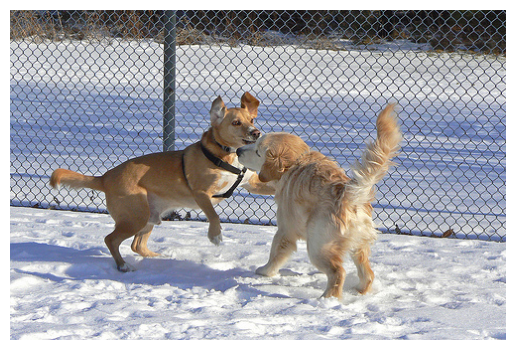

Image: 427936315_0b8f7b8d23.jpg
Caption: brown dog is running through the grass
BLEU-4: 1.0000


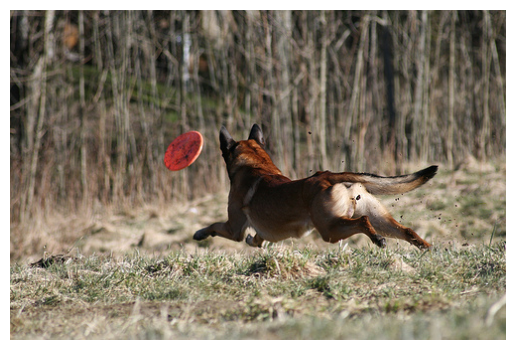

Image: 2417745327_a2c2705043.jpg
Caption: the brown dog is running through the water
BLEU-4: 0.9457


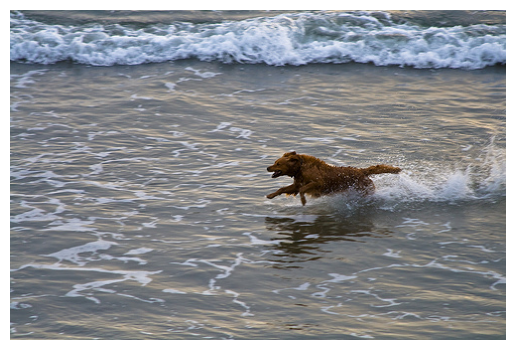

Image: 3333017828_b930b9d41b.jpg
Caption: white and brown dog is running on beach
BLEU-4: 0.8409


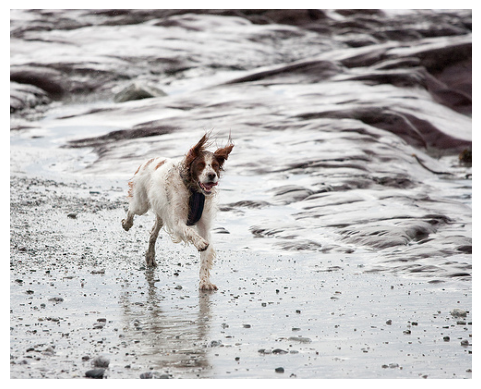

Image: 3466891862_9afde75568.jpg
Caption: dog runs through the grass
BLEU-4: 0.8409


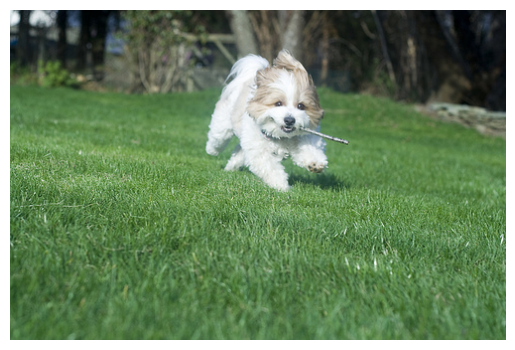


 Bottom 5 Captions by BLEU-4:

Image: 1426014905_da60d72957.jpg
Caption: two people stand on wooden bridge
BLEU-4: 0.0000


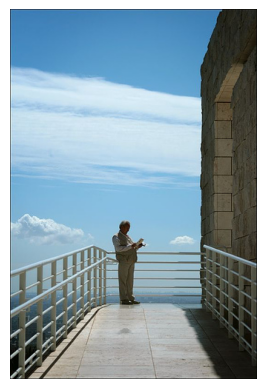

Image: 2099323664_bb20457f26.jpg
Caption: two dogs play together
BLEU-4: 0.0000


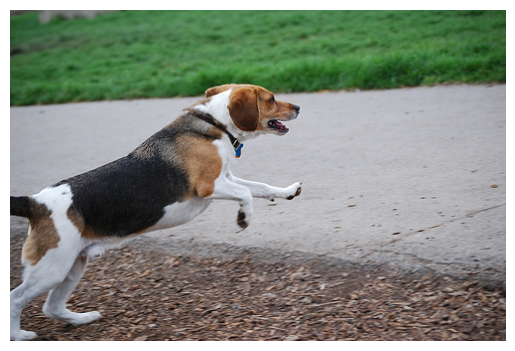

Image: 2185793891_5a5e903ca6.jpg
Caption: two young boys are talking
BLEU-4: 0.0000


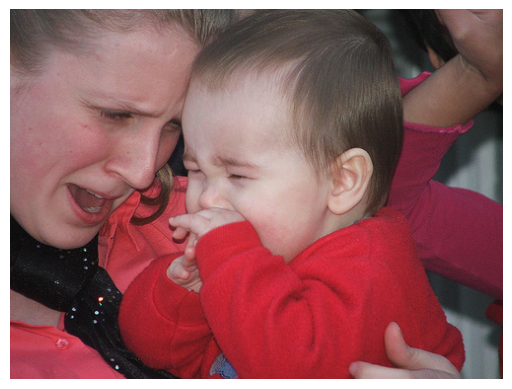

Image: 236144859_52f9e38885.jpg
Caption: two dogs are fighting
BLEU-4: 0.0000


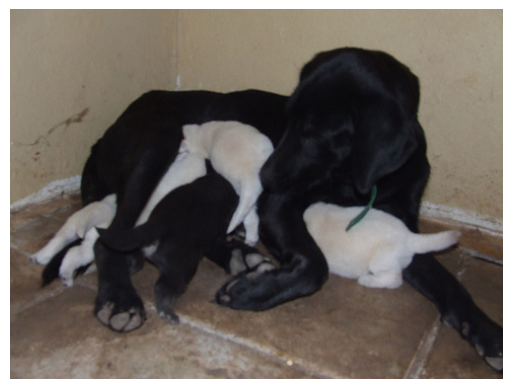

Image: 2402793046_3385554e81.jpg
Caption: man stands next to wire mesh
BLEU-4: 0.0000


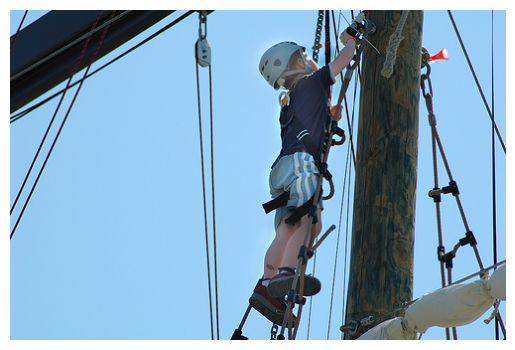

In [ ]:
def summarize_scores(results):
    bleu1_scores = [r[2] for r in results]
    bleu2_scores = [r[3] for r in results]
    bleu3_scores = [r[4] for r in results]
    bleu4_scores = [r[5] for r in results]
    meteor_scores = [r[6] for r in results]

    print("Average BLEU-1: {:.4f}".format(np.mean(bleu1_scores)))
    print("Average BLEU-2: {:.4f}".format(np.mean(bleu2_scores)))
    print("Average BLEU-3: {:.4f}".format(np.mean(bleu3_scores)))
    print("Average BLEU-4: {:.4f}".format(np.mean(bleu4_scores)))
    print("Average METEOR: {:.4f}".format(np.mean(meteor_scores)))



summarize_scores(results)
print("\n")

image_dir = "dataset/Flicker8k_Dataset/"
# Top 5 by BLEU-4
sorted_by_bleu4 = sorted(results, key=lambda x: x[5], reverse=True)
print(" Top 5 Captions by BLEU-4:\n")
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))

# # Bottom 5 by METEOR

# print("\n Bottom 5 Captions by METEOR:\n")
# sorted_by_meteor = sorted(results, key=lambda x: x[6])
# for r in sorted_by_meteor[:5]:
#     print(f"Image: {r[0]}")
#     print(f"Caption: {r[1]}")
#     print(f"METEOR: {r[6]:.4f}")
#     display_image(os.path.join(image_dir, r[0]))


## BOTTOM 5 BY BLEU

# Bottom 5 by METEOR

print("\n Bottom 5 Captions by BLEU-4:\n")
sorted_by_bleu4 = sorted(results, key=lambda x: x[5])
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))









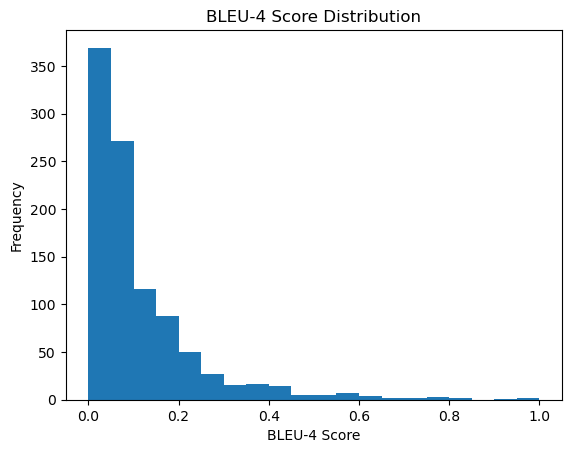

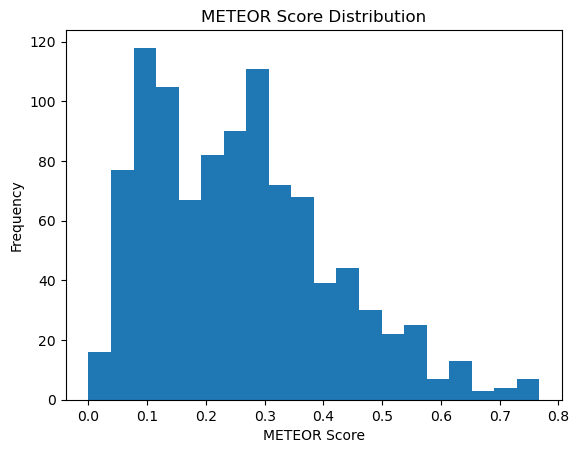

In [ ]:
import matplotlib.pyplot as plt

bleu4 = [r[5] for r in results]
meteor = [r[6] for r in results]

plt.hist(bleu4, bins=20)
plt.title("BLEU-4 Score Distribution")
plt.xlabel("BLEU-4 Score")
plt.ylabel("Frequency")
plt.show()

plt.hist(meteor, bins=20)
plt.title("METEOR Score Distribution")
plt.xlabel("METEOR Score")
plt.ylabel("Frequency")
plt.show()


In [ ]:
def evaluate_single_image(model, tokenizer, image_path, descriptions_dict, vit_model, feature_extractor, max_length):
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt")

    # Extract ViT features
    with torch.no_grad():
        outputs = vit_model(**inputs)
    photo = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy().reshape(1, 768)

    # Generate caption
    caption = generate_caption_from_features(model, tokenizer, photo, max_length)
    print(f"\n📝 Generated Caption: {caption}")

    # Get image ID
    image_id = os.path.basename(image_path)

    # Fetch reference captions
    if image_id not in descriptions_dict:
        print("⚠️ No reference captions found for this image.")
        return

    references = [d.split() for d in descriptions_dict[image_id]]
    candidate = caption.split()

    # Evaluate
    smooth = SmoothingFunction().method4
    bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
    bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
    bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
    bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    meteor = meteor_score(references, candidate)

    print(f"📊 BLEU-1: {bleu1:.4f} | BLEU-2: {bleu2:.4f} | BLEU-3: {bleu3:.4f} | BLEU-4: {bleu4:.4f}")
    print(f"🌠 METEOR: {meteor:.4f}")


📝 Generated Caption: man in red shirt is jumping in the air
📊 BLEU-1: 0.6667 | BLEU-2: 0.4082 | BLEU-3: 0.1767 | BLEU-4: 0.0989
🌠 METEOR: 0.3897


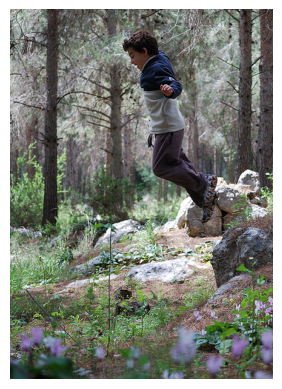

In [ ]:
# image_path = "dataset/Flicker8k_Dataset/2513260012_03d33305cf.jpg"  # Change to your image
# image_path = "dataset/pill.png" 
image_path = "dataset/Flicker8k_Dataset/3393035454_2d2370ffd4.jpg" 
# image_path = "dataset/Flicker8k_Dataset/3759230208_1c2a492b12.jpg" 
# image_path = "dataset/Flicker8k_Dataset/3767841911_6678052eb6.jpg" 
# image_path = "dataset/Flicker8k_Dataset/3726700898_c50494b8bd.jpg" 
# image_path = "dataset/Flicker8k_Dataset/3726019124_f302b3d48a.jpg" 

evaluate_single_image(
    model=model,
    tokenizer=tokenizer,
    image_path=image_path,
    descriptions_dict=clean_descriptions,
    vit_model=vit_model,
    feature_extractor=feature_extractor,
    max_length=max_length
)

# Display image
# img = Image.open(image_path)
# plt.imshow(img)
# plt.axis("off")
# plt.show()
display_image(image_path)


In [ ]:
print(tokenizer.word_index.get('<start>'))
print(tokenizer.word_index.get('<end>'))


None
None


## Testing gradio

In [ ]:
# Re-import everything after kernel reset
import sqlite3
import numpy as np
import torch
import pickle
from PIL import Image
from io import BytesIO
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import ViTFeatureExtractor, ViTModel

# Load tokenizer, model, feature extractor, and ViT
tokenizer = pickle.load(open("tokenizer.p", "rb"))
max_length = 32
caption_model = load_model("vit_caption_model.h5", custom_objects={"PositionalEncoding": PositionalEncoding})
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

# SQLite DB
DB_FILE = "images.db"

# Initialize DB
def init_db():
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS images (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                image BLOB NOT NULL,
                caption TEXT NOT NULL,
                embedding BLOB NOT NULL
            )
        ''')
        conn.commit()

init_db()

# Helper: decode predicted word
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

# Caption generation from features
def generate_caption_from_features(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        # Tokenize and pad input
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')

        # Predict next word
        preds = model.predict([photo, sequence], verbose=0)
        next_token = np.argmax(preds[0, i])  # Get i-th position in sequence

        word = word_for_id(next_token, tokenizer)
        if word is None or word == 'end':
            break
        in_text += ' ' + word

    return in_text.replace('start', '').replace('end', '').strip()

# Full image captioning + save
def generate_caption(image_path):
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt")

    # Extract ViT features using mean pooling
    with torch.no_grad():
        vit_features = vit_model(**inputs).last_hidden_state.mean(dim=1)

    # Convert to NumPy and normalize for search compatibility
    photo = vit_features.reshape(1, 768).numpy()
    photo_norm = photo / np.linalg.norm(photo)

    # Generate caption using your model
    caption = generate_caption_from_features(caption_model, tokenizer, photo_norm, max_length)

    # Save image, caption, and embedding
    saveImageDesc(image_path, caption, photo_norm.squeeze())

    return caption



# Save image + caption + embedding
def saveImageDesc(img_path, caption, embedding):
    img = Image.open(img_path)
    img_bytes = BytesIO()
    img.save(img_bytes, format="PNG")
    img_data = img_bytes.getvalue()
    emb_blob = pickle.dumps(embedding)

    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("INSERT INTO images (image, caption, embedding) VALUES (?, ?, ?)", 
                       (img_data, caption, emb_blob))
        conn.commit()

# Text-to-image (caption-based keyword match)
from PIL import Image

def image_to_image_search(query_image, threshold=0.80):
    # Handle both filepath (upload) and in-memory image (webcam)
    if isinstance(query_image, str):  # File path
        query_img = Image.open(query_image).convert("RGB")
    elif isinstance(query_image, Image.Image):  # Webcam or direct PIL input
        query_img = query_image.convert("RGB")
    else:
        raise ValueError("Invalid input: must be a file path or a PIL.Image")

    inputs = feature_extractor(images=query_img, return_tensors="pt")
    with torch.no_grad():
        query_embedding = vit_model(**inputs).last_hidden_state.mean(dim=1).squeeze().numpy()
        query_embedding /= np.linalg.norm(query_embedding)

    results = []
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image, caption, embedding FROM images")
        for img_data, caption, emb_blob in cursor.fetchall():
            stored_embedding = pickle.loads(emb_blob)
            stored_embedding /= np.linalg.norm(stored_embedding)
            sim = cosine_similarity([query_embedding], [stored_embedding])[0][0]
            if sim >= threshold:
                results.append((sim, img_data, caption))

    results.sort(reverse=True, key=lambda x: x[0])
    top_results = results[:5]

    display_images = []
    for sim, img_bytes, caption in top_results:
        img = Image.open(BytesIO(img_bytes))
        caption_with_score = f"Sim: {sim:.2f} | {caption}"
        display_images.append((img, caption_with_score))

    return display_images

# Text-to-image (caption-based keyword match)
def search_images(keyword):
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image FROM images WHERE caption LIKE ?", ('%' + keyword + '%',))
        rows = cursor.fetchall()
    images = [Image.open(BytesIO(row[0])) for row in rows] if rows else []
    return gr.Gallery(images, columns=2)



# Gradio Interfaces
caption_iface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="filepath"),
    outputs="text",
    title="Image Caption Generator",
    description="Upload an image to generate a caption and store it locally."
)

search_text_iface = gr.Interface(
    fn=search_images,
    inputs="text",
    outputs=gr.Gallery(),
    title="Search Images by Text",
    description="Search images based on their generated captions."
)

search_image_iface = gr.Interface(
    fn=image_to_image_search,
    inputs=[
        gr.Image(type="filepath", label="Query Image"),
        gr.Slider(0.0, 1.0, step=0.01, value=0.80, label="Similarity Threshold")
    ],
    outputs=gr.Gallery(),
    title="Search Images by Image",
    description="Upload an image and filter similar results by cosine similarity."
)


# Launch all interfaces
gr.TabbedInterface(
    [caption_iface, search_text_iface, search_image_iface],
    ["Generate Caption", "Search by Text", "Search by Image"]
).launch()


NameError: name 'search_images' is not defined

IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------


In [ ]:
# import gradio as gr
# import sqlite3
# import numpy as np
# from tensorflow.keras.models import load_model
# from PIL import Image
# import io
# import pickle
# from tensorflow.keras.applications.xception import Xception


# import pickle
# tokenizer = pickle.load(open("tokenizer.p", "rb"))
# max_length = 32  # or load this from config if saved


# # Load trained image captioning model
# # model = load_model('models/model_8.h5')
# caption_model = load_model('vit_caption_model.h5')

# # SQLite database file
# DB_FILE = "images.db"

# # Create table if not exists
# def init_db():
#     with sqlite3.connect(DB_FILE) as conn:
#         cursor = conn.cursor()
#         cursor.execute('''
#             CREATE TABLE IF NOT EXISTS images (
#                 id INTEGER PRIMARY KEY AUTOINCREMENT,
#                 image BLOB NOT NULL,
#                 caption TEXT NOT NULL
#             )
#         ''')
#         conn.commit()

# init_db()

# import gradio as gr
# from PIL import Image
# import torch

# def generate_caption(image_path):
#     image = Image.open(image_path).convert("RGB")
#     inputs = feature_extractor(images=image, return_tensors="pt")
#     with torch.no_grad():
#         vit_features = vit_model(**inputs).last_hidden_state.mean(dim=1)
#     photo = vit_features.reshape(1, 768).numpy()

#     # Call the reusable function
#     caption = generate_caption_from_features(caption_model, tokenizer, photo, max_length)
#     saveImageDesc(image_path, caption)
#     return caption



# def saveImageDesc(img_path, caption):
#     img = Image.open(img_path)

#     # Convert image to bytes for storing in SQLite
#     img_bytes = io.BytesIO()
#     img.save(img_bytes, format="PNG")
#     img_data = img_bytes.getvalue()

#     # Store in SQLite
#     with sqlite3.connect(DB_FILE) as conn:
#         cursor = conn.cursor()
#         cursor.execute("INSERT INTO images (image, caption) VALUES (?, ?)", (img_data, caption))
#         cursor.execute('''
#             CREATE TABLE IF NOT EXISTS images (
#                 id INTEGER PRIMARY KEY AUTOINCREMENT,
#                 image BLOB NOT NULL,
#                 caption TEXT NOT NULL,
#                 embedding BLOB NOT NULL
#             )
#         ''')
#         conn.commit()
#         print(f"{img_path} added to database.")

# # **Updated Search Function for Multiple Images**
# def search_images(keyword):
#     with sqlite3.connect(DB_FILE) as conn:
#         cursor = conn.cursor()
#         cursor.execute("SELECT image FROM images WHERE caption LIKE ?", ('%' + keyword + '%',))
#         rows = cursor.fetchall()  # Fetch all matching rows

#     if rows:
#         images = [Image.open(io.BytesIO(row[0])) for row in rows]  # Convert binary data to images
#         # Return the list of images as a Gradio gallery, set columns to 2 directly
#         return gr.Gallery(images, columns=2)  # Display images in 2 columns
#     else:
#         return gr.Gallery([])  # Return a message if no image is found

# # Create Gradio UI for caption generation
# iface = gr.Interface(
#     fn=generate_caption,
#     inputs=gr.Image(type="filepath"),
#     outputs="text",
#     title="Image Caption Generator",
#     description="Upload an image to generate a caption and store it locally."
# )

# # Create Gradio UI for searching images by caption
# search_iface = gr.Interface(
#     fn=search_images,
#     inputs="text",
#     outputs=gr.Gallery(),  # Use Gallery to display multiple images
#     title="Search Images by Caption",
#     description="Enter a keyword to find images stored in SQLite.",
#     examples=[["man"], ["dog"], ["nature"]]  # Add sample keywords for testing
# )

# # Launch both interfaces in tabs
# gr.TabbedInterface([iface, search_iface], ["Generate Caption", "Search Images"]).launch()
